#Distributed FinTech Time-Series Forecasting using PySpark on the Bitcoin Dataset
In this assessment lab, you will independently implement a distributed time-series
forecasting system using PySpark to predict cryptocurrency prices. Building on the
Guided Lab, you must adapt the same forecasting pipeline to the Bitcoin Historical
Data dataset, which contains real-world financial time-series data. The task requires
you to load the dataset into a Spark DataFrame, preprocess and organise the data
chronologically, generate temporal features using window functions, and transform
the time-series into a supervised learning format for forecasting.
You must implement the complete pipeline, including feature engineering using lag
and rolling statistical features, creation of a target variable representing future price
values, and a time-based train–test split to avoid data leakage. Distributed
regression models such as Linear Regression and Gradient Boosted Trees should
be trained and used to generate predictions. The models must be evaluated using
appropriate regression metrics such as RMSE and MAE, and the results should be
analysed to assess forecasting performance.
Your submission should clearly demonstrate the full workflow by providing evidence
of data loading, preprocessing, feature generation, model training, prediction
outputs, and evaluation results. The objective of this assessment is to evaluate your
ability to apply distributed machine learning techniques in PySpark and adapt a
forecasting pipeline to a new financial dataset in a real-world fintech scenario.
#Dataset Description
The Bitcoin Historical Data dataset 1contains time-series financial data, including
attributes such as Timestamp, Open, High, Low, Close, Volume, and Weighted
Price. The Close price is used as the target variable for forecasting future values.
This is a time-series forecasting problem where historical cryptocurrency prices are
used to predict future price movements. The dataset is chronologically ordered and
requires time-aware processing to ensure correct modelling and avoid data leakage.

In [36]:
# Install PySpark if required
!pip -q install pyspark

import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import (
    col,
    from_unixtime,
    to_timestamp,
    to_date,
    lag,
    lead,
    stddev,
    avg,
    row_number,
    hour,
    dayofweek,
    month
)

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

In [37]:
data_file = "/content/btcusd_1-min_data.csv"

spark = SparkSession.builder \
    .appName("Bitcoin_Forecasting_Advanced") \
    .getOrCreate()

spark_df = spark.read.csv(
    data_file,
    header=True,
    inferSchema=True
)

print("✅ Dataset loaded successfully")
print(f"Number of rows: {spark_df.count():,}")

spark_df.printSchema()
spark_df.show(10)

✅ Dataset loaded successfully
Number of rows: 7,685,335
root
 |-- Timestamp: integer (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)

+----------+----+----+----+-----+------+
| Timestamp|Open|High| Low|Close|Volume|
+----------+----+----+----+-----+------+
|1325376060|4.58|4.58|4.58| 4.58|   0.0|
|1325376120|4.58|4.58|4.58| 4.58|   0.0|
|1325376180|4.58|4.58|4.58| 4.58|   0.0|
|1325376240|4.58|4.58|4.58| 4.58|   0.0|
|1325376300|4.58|4.58|4.58| 4.58|   0.0|
|1325376360|4.58|4.58|4.58| 4.58|   0.0|
|1325376420|4.58|4.58|4.58| 4.58|   0.0|
|1325376480|4.58|4.58|4.58| 4.58|   0.0|
|1325376540|4.58|4.58|4.58| 4.58|   0.0|
|1325376600|4.58|4.58|4.58| 4.58|   0.0|
+----------+----+----+----+-----+------+
only showing top 10 rows


In [38]:
df = (
    spark_df
    .withColumn(
        "Timestamp",
        to_timestamp(
            from_unixtime(col("Timestamp").cast("long"))
        )
    )
    .withColumn(
        "Date",
        to_date(col("Timestamp"))
    )
    .select(
        "Timestamp",
        "Date",
        col("Open").cast("double").alias("Open"),
        col("High").cast("double").alias("High"),
        col("Low").cast("double").alias("Low"),
        col("Close").cast("double").alias("Close"),
        col("Volume").cast("double").alias("Volume")
    )
    .dropna()
    .orderBy("Timestamp")
)

print("✅ Timestamp conversion and preprocessing complete")

df.printSchema()
df.show(10, truncate=False)

✅ Timestamp conversion and preprocessing complete
root
 |-- Timestamp: timestamp (nullable = true)
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)

+-------------------+----------+----+----+----+-----+------+
|Timestamp          |Date      |Open|High|Low |Close|Volume|
+-------------------+----------+----+----+----+-----+------+
|2012-01-01 00:01:00|2012-01-01|4.58|4.58|4.58|4.58 |0.0   |
|2012-01-01 00:02:00|2012-01-01|4.58|4.58|4.58|4.58 |0.0   |
|2012-01-01 00:03:00|2012-01-01|4.58|4.58|4.58|4.58 |0.0   |
|2012-01-01 00:04:00|2012-01-01|4.58|4.58|4.58|4.58 |0.0   |
|2012-01-01 00:05:00|2012-01-01|4.58|4.58|4.58|4.58 |0.0   |
|2012-01-01 00:06:00|2012-01-01|4.58|4.58|4.58|4.58 |0.0   |
|2012-01-01 00:07:00|2012-01-01|4.58|4.58|4.58|4.58 |0.0   |
|2012-01-01 00:08:00|2012-01-01|4.58|4.58|4.58|4.58 |0.0   |
|2012-01-01 0

In [39]:
from pyspark.sql.functions import min, max

print("Dataset shape:")
print(f"Rows: {df.count():,}")
print(f"Columns: {len(df.columns)}")

print("\nDate range:")
df.select(
    min("Timestamp").alias("Start"),
    max("Timestamp").alias("End")
).show()

print("\nSummary statistics:")
df.select(
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
).describe().show()

Dataset shape:
Rows: 7,685,335
Columns: 7

Date range:
+-------------------+-------------------+
|              Start|                End|
+-------------------+-------------------+
|2012-01-01 00:01:00|2026-08-12 00:55:00|
+-------------------+-------------------+


Summary statistics:
+-------+------------------+-----------------+------------------+------------------+------------------+
|summary|              Open|             High|               Low|             Close|            Volume|
+-------+------------------+-----------------+------------------+------------------+------------------+
|  count|           7685335|          7685335|           7685335|           7685335|           7685335|
|   mean| 23782.58099331756|23790.80014851889|23774.194220044028|23782.600951040033| 4.955856574928095|
| stddev|31392.579460632038|31400.92536244987|31384.184440348745| 31392.60394859779|21.564678639214186|
|    min|               3.8|              3.8|               3.8|               3.8|     

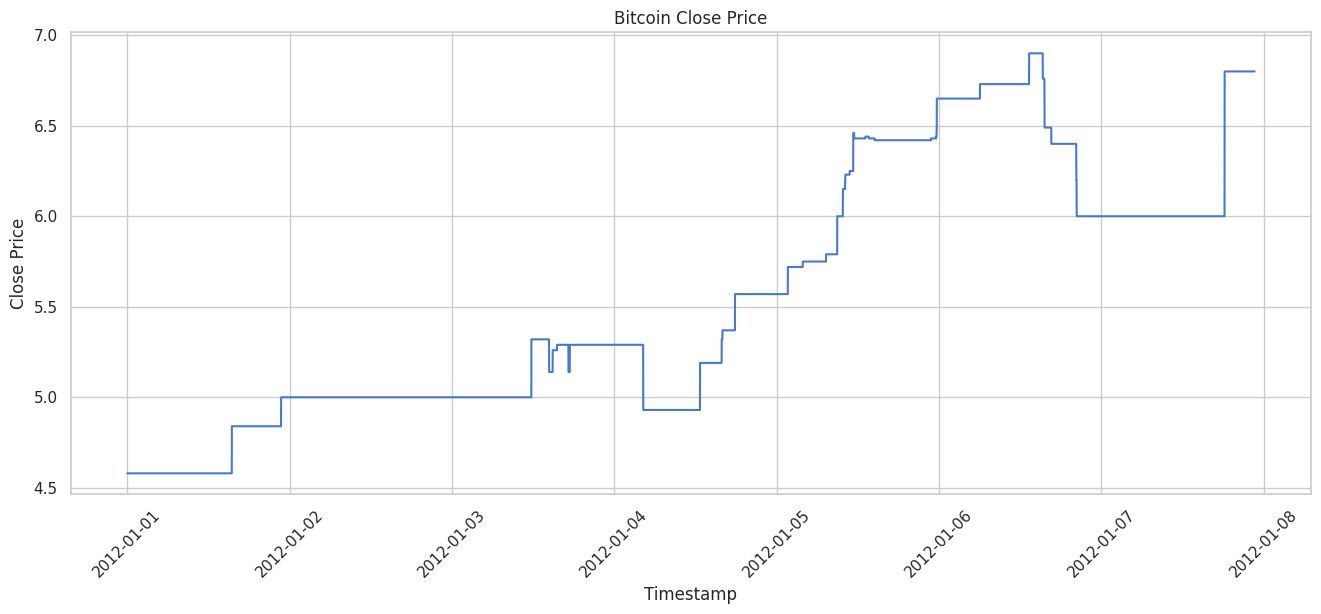

In [40]:
plot_df = (
    df.select("Timestamp", "Close")
      .orderBy("Timestamp")
      .limit(10000)
      .toPandas()
)

plt.figure(figsize=(16, 6))
plt.plot(plot_df["Timestamp"], plot_df["Close"])
plt.title("Bitcoin Close Price")
plt.xlabel("Timestamp")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [41]:
time_window = Window.orderBy("Timestamp")

rolling_5 = time_window.rowsBetween(-4, 0)
rolling_20 = time_window.rowsBetween(-19, 0)

In [42]:
features_df = (
    df

    # Previous close
    .withColumn(
        "Prev_Close",
        lag("Close", 1).over(time_window)
    )

    # 1-minute return
    .withColumn(
        "Return_1m",
        (col("Close") - col("Prev_Close")) / col("Prev_Close")
    )

    # Lagged returns
    .withColumn(
        "Lag_1_Return",
        lag("Return_1m", 1).over(time_window)
    )

    .withColumn(
        "Lag_2_Return",
        lag("Return_1m", 2).over(time_window)
    )

    # Rolling volatility
    .withColumn(
        "RollingStd_5",
        stddev("Return_1m").over(rolling_5)
    )

    .withColumn(
        "RollingStd_20",
        stddev("Return_1m").over(rolling_20)
    )

    # Rolling average price
    .withColumn(
        "RollingAvg_5",
        avg("Close").over(rolling_5)
    )

    .withColumn(
        "RollingAvg_20",
        avg("Close").over(rolling_20)
    )

    # Time features
    .withColumn("Hour", hour("Timestamp"))
    .withColumn("DayOfWeek", dayofweek("Timestamp"))
    .withColumn("Month", month("Timestamp"))

    # ML TARGET:
    # Predict the next 1-minute closing price
    .withColumn(
        "Target_Next_Close",
        lead("Close", 1).over(time_window)
    )

    .dropna()
)

print("✅ Feature engineering complete")

features_df.select(
    "Timestamp",
    "Close",
    "Return_1m",
    "Lag_1_Return",
    "Lag_2_Return",
    "RollingStd_5",
    "RollingStd_20",
    "Target_Next_Close"
).show(10, truncate=False)

✅ Feature engineering complete
+-------------------+-----+---------+------------+------------+------------+-------------+-----------------+
|Timestamp          |Close|Return_1m|Lag_1_Return|Lag_2_Return|RollingStd_5|RollingStd_20|Target_Next_Close|
+-------------------+-----+---------+------------+------------+------------+-------------+-----------------+
|2012-01-01 00:04:00|4.58 |0.0      |0.0         |0.0         |0.0         |0.0          |4.58             |
|2012-01-01 00:05:00|4.58 |0.0      |0.0         |0.0         |0.0         |0.0          |4.58             |
|2012-01-01 00:06:00|4.58 |0.0      |0.0         |0.0         |0.0         |0.0          |4.58             |
|2012-01-01 00:07:00|4.58 |0.0      |0.0         |0.0         |0.0         |0.0          |4.58             |
|2012-01-01 00:08:00|4.58 |0.0      |0.0         |0.0         |0.0         |0.0          |4.58             |
|2012-01-01 00:09:00|4.58 |0.0      |0.0         |0.0         |0.0         |0.0          |4.58   

In [43]:
split_window = Window.orderBy("Timestamp")

features_df = features_df.withColumn(
    "row_num",
    row_number().over(split_window)
)

total_rows = features_df.count()

split_index = int(total_rows * 0.80)

train_df = features_df.filter(
    col("row_num") <= split_index
)

test_df = features_df.filter(
    col("row_num") > split_index
)

print(f"Total observations: {total_rows:,}")
print(f"Training observations: {train_df.count():,}")
print(f"Testing observations: {test_df.count():,}")

print("\nTraining period:")
train_df.select(
    min("Timestamp").alias("Start"),
    max("Timestamp").alias("End")
).show()

print("Testing period:")
test_df.select(
    min("Timestamp").alias("Start"),
    max("Timestamp").alias("End")
).show()

Total observations: 7,685,331
Training observations: 6,148,264
Testing observations: 1,537,067

Training period:
+-------------------+-------------------+
|              Start|                End|
+-------------------+-------------------+
|2012-01-01 00:04:00|2023-09-09 15:07:00|
+-------------------+-------------------+

Testing period:
+-------------------+-------------------+
|              Start|                End|
+-------------------+-------------------+
|2023-09-09 15:08:00|2026-08-12 00:54:00|
+-------------------+-------------------+



In [44]:
feature_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return_1m",
    "Lag_1_Return",
    "Lag_2_Return",
    "RollingStd_5",
    "RollingStd_20",
    "RollingAvg_5",
    "RollingAvg_20",
    "Hour",
    "DayOfWeek",
    "Month"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="raw_features",
    handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)

In [45]:
lr = LinearRegression(
    featuresCol="scaled_features",
    labelCol="Target_Next_Close",
    predictionCol="lr_prediction",
    maxIter=10
)

lr_pipeline = Pipeline(
    stages=[
        assembler,
        scaler,
        lr
    ]
)

print("✅ Linear Regression pipeline created")

✅ Linear Regression pipeline created


In [46]:
print("🏋️ Training Linear Regression...")

lr_model = lr_pipeline.fit(train_df)

lr_predictions = lr_model.transform(test_df)

print("✅ Linear Regression training complete")

lr_predictions.select(
    "Timestamp",
    "Close",
    "Target_Next_Close",
    "lr_prediction"
).show(10)

🏋️ Training Linear Regression...
✅ Linear Regression training complete
+-------------------+-------+-----------------+------------------+
|          Timestamp|  Close|Target_Next_Close|     lr_prediction|
+-------------------+-------+-----------------+------------------+
|2023-09-09 15:08:00|25901.0|          25884.0| 25900.56959269428|
|2023-09-09 15:09:00|25884.0|          25874.0| 25884.07716498323|
|2023-09-09 15:10:00|25874.0|          25877.0|25874.269596004033|
|2023-09-09 15:11:00|25877.0|          25886.0|25876.802557746385|
|2023-09-09 15:12:00|25886.0|          25882.0| 25885.57872545002|
|2023-09-09 15:13:00|25882.0|          25877.0|25881.429268249733|
|2023-09-09 15:14:00|25877.0|          25878.0|25876.493979365983|
|2023-09-09 15:15:00|25878.0|          25889.0|25877.411454943853|
|2023-09-09 15:16:00|25889.0|          25885.0|25888.649463010952|
|2023-09-09 15:17:00|25885.0|          25887.0| 25884.71305706053|
+-------------------+-------+-----------------+-----------

In [47]:
gbt = GBTRegressor(
    featuresCol="raw_features",
    labelCol="Target_Next_Close",
    predictionCol="gbt_prediction",
    maxIter=10,
    maxDepth=3,
    seed=42
)

gbt_pipeline = Pipeline(
    stages=[
        assembler,
        gbt
    ]
)

print("🌲 GBT pipeline created")

🌲 GBT pipeline created


In [31]:
print("🌲 Training Gradient Boosted Trees...")

gbt_model = gbt_pipeline.fit(train_df)

gbt_predictions = gbt_model.transform(test_df)

print("✅ Gradient Boosted Trees training complete")

gbt_predictions.select(
    "Timestamp",
    "Close",
    "Target_Next_Close",
    "gbt_prediction"
).show(10)

🌲 Training Gradient Boosted Trees...
✅ Gradient Boosted Trees training complete
+-------------------+-------+-----------------+------------------+
|          Timestamp|  Close|Target_Next_Close|    gbt_prediction|
+-------------------+-------+-----------------+------------------+
|2023-09-09 15:08:00|25901.0|          25884.0|30643.748198939033|
|2023-09-09 15:09:00|25884.0|          25874.0|30643.748198939033|
|2023-09-09 15:10:00|25874.0|          25877.0|30643.748198939033|
|2023-09-09 15:11:00|25877.0|          25886.0|30643.748198939033|
|2023-09-09 15:12:00|25886.0|          25882.0|30643.748198939033|
|2023-09-09 15:13:00|25882.0|          25877.0|30643.748198939033|
|2023-09-09 15:14:00|25877.0|          25878.0|30643.748198939033|
|2023-09-09 15:15:00|25878.0|          25889.0|30643.748198939033|
|2023-09-09 15:16:00|25889.0|          25885.0|30643.748198939033|
|2023-09-09 15:17:00|25885.0|          25887.0|30643.748198939033|
+-------------------+-------+-----------------+--

In [32]:
def evaluate_model(predictions, prediction_col, model_name):

    rmse_evaluator = RegressionEvaluator(
        labelCol="Target_Next_Close",
        predictionCol=prediction_col,
        metricName="rmse"
    )

    mae_evaluator = RegressionEvaluator(
        labelCol="Target_Next_Close",
        predictionCol=prediction_col,
        metricName="mae"
    )

    r2_evaluator = RegressionEvaluator(
        labelCol="Target_Next_Close",
        predictionCol=prediction_col,
        metricName="r2"
    )

    rmse = rmse_evaluator.evaluate(predictions)
    mae = mae_evaluator.evaluate(predictions)
    r2 = r2_evaluator.evaluate(predictions)

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


results = pd.DataFrame([
    evaluate_model(
        lr_predictions,
        "lr_prediction",
        "Linear Regression"
    ),

    evaluate_model(
        gbt_predictions,
        "gbt_prediction",
        "Gradient Boosted Trees"
    )
])

results

,Model,RMSE,MAE,R2
0,Linear Regression,50.760676,30.378641,0.999996
1,Gradient Boosted Trees,32431.115695,25827.018878,-0.781593


In [33]:
display(results.style.format({
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}",
    "R2": "{:.4f}"
}))

,Model,RMSE,MAE,R2
0,Linear Regression,50.7607,30.3786,1.0000
1,Gradient Boosted Trees,32431.1157,25827.0189,-0.7816


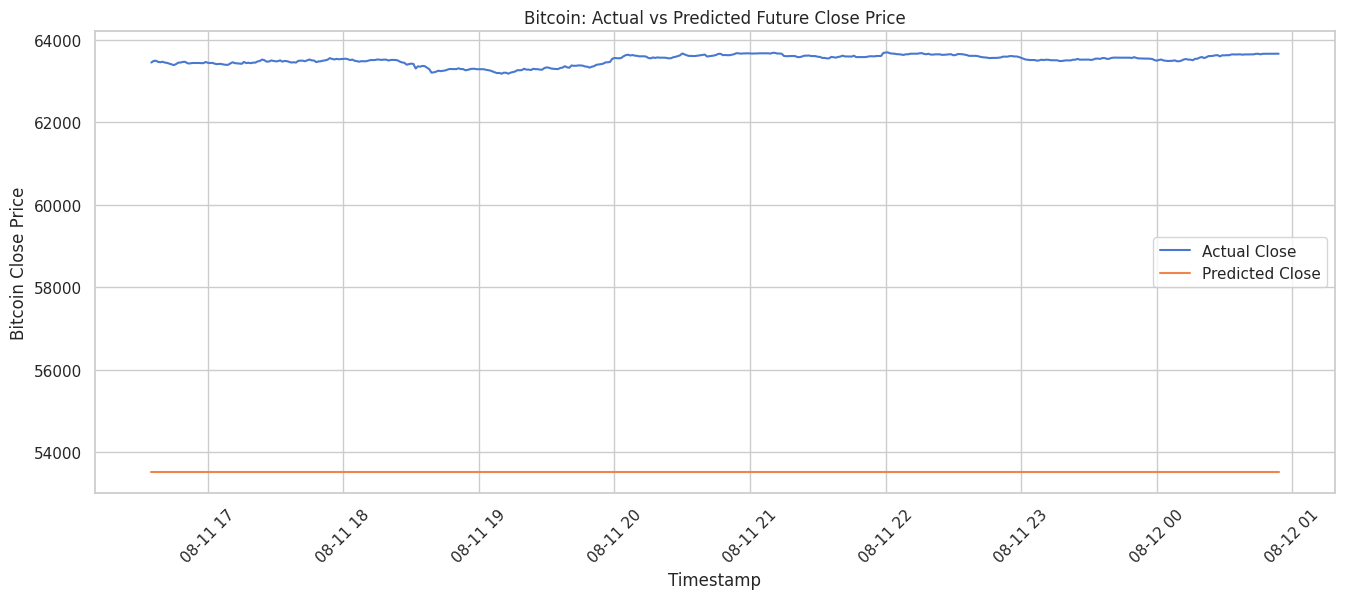

In [34]:
plot_df = (
    gbt_predictions
    .select(
        "Timestamp",
        "Target_Next_Close",
        "gbt_prediction"
    )
    .orderBy("Timestamp")
    .tail(500)
)

plot_pdf = pd.DataFrame(
    plot_df,
    columns=[
        "Timestamp",
        "Actual_Close",
        "Predicted_Close"
    ]
)

plot_pdf["Timestamp"] = pd.to_datetime(
    plot_pdf["Timestamp"]
)

plt.figure(figsize=(16, 6))

plt.plot(
    plot_pdf["Timestamp"],
    plot_pdf["Actual_Close"],
    label="Actual Close"
)

plt.plot(
    plot_pdf["Timestamp"],
    plot_pdf["Predicted_Close"],
    label="Predicted Close"
)

plt.title(
    "Bitcoin: Actual vs Predicted Future Close Price"
)

plt.xlabel("Timestamp")
plt.ylabel("Bitcoin Close Price")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

In [35]:
gbt_predictions.select(
    "Timestamp",
    "Close",
    "Target_Next_Close",
    "gbt_prediction"
).orderBy("Timestamp").show(20, truncate=False)

+-------------------+-------+-----------------+------------------+
|Timestamp          |Close  |Target_Next_Close|gbt_prediction    |
+-------------------+-------+-----------------+------------------+
|2023-09-09 15:08:00|25901.0|25884.0          |30643.748198939033|
|2023-09-09 15:09:00|25884.0|25874.0          |30643.748198939033|
|2023-09-09 15:10:00|25874.0|25877.0          |30643.748198939033|
|2023-09-09 15:11:00|25877.0|25886.0          |30643.748198939033|
|2023-09-09 15:12:00|25886.0|25882.0          |30643.748198939033|
|2023-09-09 15:13:00|25882.0|25877.0          |30643.748198939033|
|2023-09-09 15:14:00|25877.0|25878.0          |30643.748198939033|
|2023-09-09 15:15:00|25878.0|25889.0          |30643.748198939033|
|2023-09-09 15:16:00|25889.0|25885.0          |30643.748198939033|
|2023-09-09 15:17:00|25885.0|25887.0          |30643.748198939033|
|2023-09-09 15:18:00|25887.0|25890.0          |30643.748198939033|
|2023-09-09 15:19:00|25890.0|25887.0          |30643.748198939

## Summary

This assessment implemented a distributed cryptocurrency time-series forecasting pipeline using PySpark and the Bitcoin Historical Data dataset. The original Unix timestamps were converted into Spark timestamps and the financial records were organised chronologically before feature engineering.

Several temporal and statistical features were generated using Spark window functions, including lagged returns, rolling volatility, rolling average prices, and calendar-based features. The target variable was created using the next available Bitcoin closing price, allowing the problem to be transformed into a supervised learning task.

To avoid data leakage, the dataset was divided using a chronological 80/20 train-test split rather than a random split. Linear Regression and Gradient Boosted Trees were then trained using PySpark ML pipelines.

The models were evaluated using RMSE and MAE, with R² also reported as an additional metric. Lower RMSE and MAE indicate better forecasting performance. The final comparison shows which model provides the most accurate predictions on the unseen future portion of the Bitcoin dataset.

Overall, the assessment demonstrates how PySpark can be used to process financial time-series data in a distributed environment and build machine learning models for cryptocurrency price forecasting while maintaining time-aware preprocessing and avoiding future-data leakage.
